# Lesson 07 — Logistic Regression — Intro

<h2 dir="rtl">פרק 1 — פתיחה: סיפור Challenger</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

<h2 dir="rtl">פרק 2 — OLS על מספר כשלים</h2>

   num_failure  temp  intercept
0            0    66          1
1            1    70          1
2            0    69          1
3            0    68          1
4            0    67          1

shape: (23, 3)


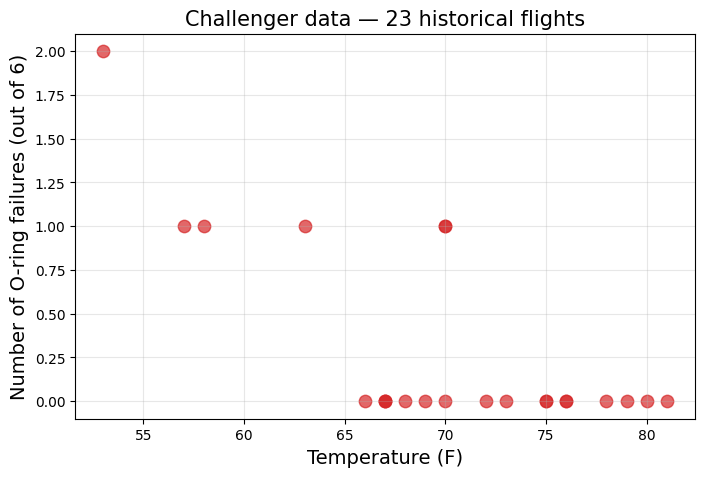

In [2]:
data = pd.read_csv('oring.csv')
data['intercept'] = 1
print(data.head())
print(f'\nshape: {data.shape}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(data['temp'], data['num_failure'], s=80, alpha=0.7, color='tab:red')
ax.set_xlabel('Temperature (F)', fontsize=14)
ax.set_ylabel('Number of O-ring failures (out of 6)', fontsize=14)
ax.set_title('Challenger data — 23 historical flights', fontsize=15)
ax.grid(alpha=0.3)
plt.show()

                            OLS Regression Results                            
Dep. Variable:            num_failure   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     23.53
Date:                Mon, 25 May 2026   Prob (F-statistic):           8.53e-05
Time:                        15:59:38   Log-Likelihood:                -10.095
No. Observations:                  23   AIC:                             24.19
Df Residuals:                      21   BIC:                             26.46
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      4.1543      0.798      5.207      0.0

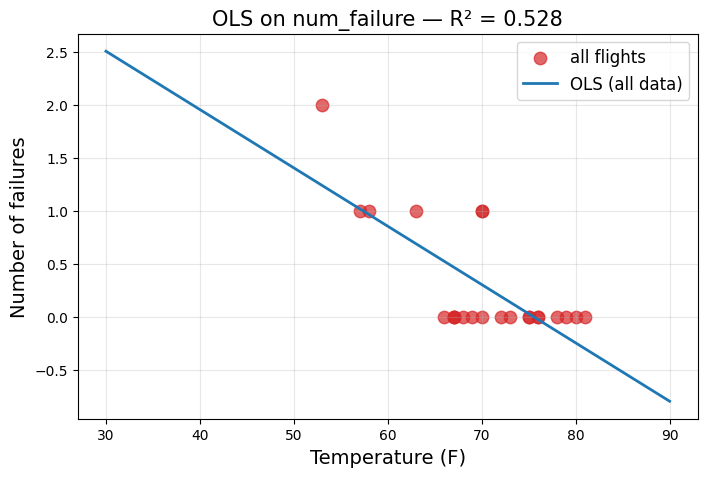

In [3]:
model_full = sm.OLS(data['num_failure'], data[['intercept', 'temp']]).fit()
print(model_full.summary())

temp_grid = np.linspace(30, 90, 100)
grid_df = pd.DataFrame({'intercept': 1, 'temp': temp_grid})
y_pred_full = model_full.predict(grid_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(data['temp'], data['num_failure'], s=80, alpha=0.7, color='tab:red', label='all flights')
ax.plot(temp_grid, y_pred_full, color='tab:blue', linewidth=2, label='OLS (all data)')
ax.set_xlabel('Temperature (F)', fontsize=14)
ax.set_ylabel('Number of failures', fontsize=14)
ax.set_title(f'OLS on num_failure — R² = {model_full.rsquared:.3f}', fontsize=15)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.show()

<h2 dir="rtl">פרק 3 — Survivorship Bias</h2>

In [4]:
data_filtered = data[data['num_failure'] > 0].copy()
print(f'Filtered data: {data_filtered.shape[0]} flights (where failure occurred)')

model_filt = sm.OLS(data_filtered['num_failure'], data_filtered[['intercept', 'temp']]).fit()
print(model_filt.summary())

Filtered data: 6 flights (where failure occurred)
                            OLS Regression Results                            
Dep. Variable:            num_failure   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     2.383
Date:                Mon, 25 May 2026   Prob (F-statistic):              0.198
Time:                        15:59:38   Log-Likelihood:                -1.1896
No. Observations:                   6   AIC:                             6.379
Df Residuals:                       4   BIC:                             5.963
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
in

C:\Users\razel\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


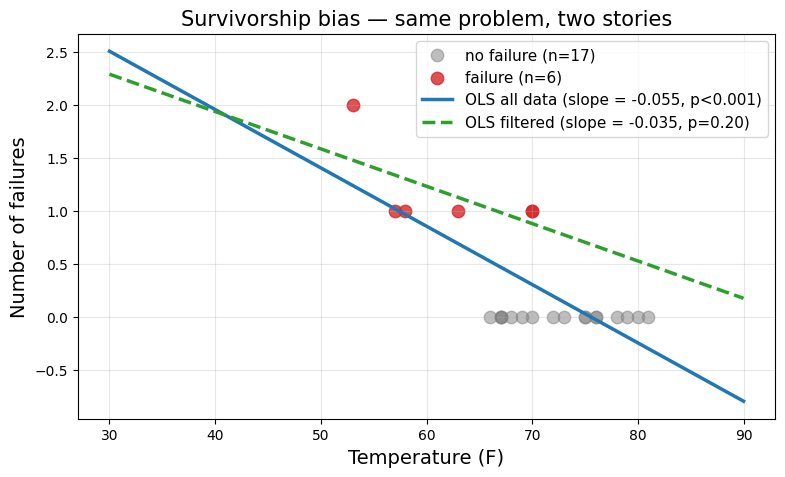

In [5]:
y_pred_filt = model_filt.predict(grid_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(data[data['num_failure']==0]['temp'], data[data['num_failure']==0]['num_failure'],
           s=80, alpha=0.5, color='tab:gray', label='no failure (n=17)')
ax.scatter(data_filtered['temp'], data_filtered['num_failure'],
           s=80, alpha=0.8, color='tab:red', label='failure (n=6)')
ax.plot(temp_grid, y_pred_full, color='tab:blue', linewidth=2.5,
        label=f'OLS all data (slope = {model_full.params["temp"]:.3f}, p<0.001)')
ax.plot(temp_grid, y_pred_filt, color='tab:green', linewidth=2.5, linestyle='--',
        label=f'OLS filtered (slope = {model_filt.params["temp"]:.3f}, p={model_filt.pvalues["temp"]:.2f})')
ax.set_xlabel('Temperature (F)', fontsize=14)
ax.set_ylabel('Number of failures', fontsize=14)
ax.set_title('Survivorship bias — same problem, two stories', fontsize=15)
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3)
plt.show()

<h2 dir="rtl">פרק 4 — המרה ל-binary + OLS שובר</h2>

In [6]:
data['failure'] = (data['num_failure'] >= 1).astype(int)
print(f"failure=1 (any failure): {data['failure'].sum()}")
print(f"failure=0 (no failure):  {(data['failure']==0).sum()}")

model_lin_bin = sm.OLS(data['failure'], data[['intercept', 'temp']]).fit()
print(model_lin_bin.summary())

failure=1 (any failure): 6
failure=0 (no failure):  17
                            OLS Regression Results                            
Dep. Variable:                failure   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     17.26
Date:                Mon, 25 May 2026   Prob (F-statistic):           0.000449
Time:                        15:59:38   Log-Likelihood:                -6.8068
No. Observations:                  23   AIC:                             17.61
Df Residuals:                      21   BIC:                             19.88
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

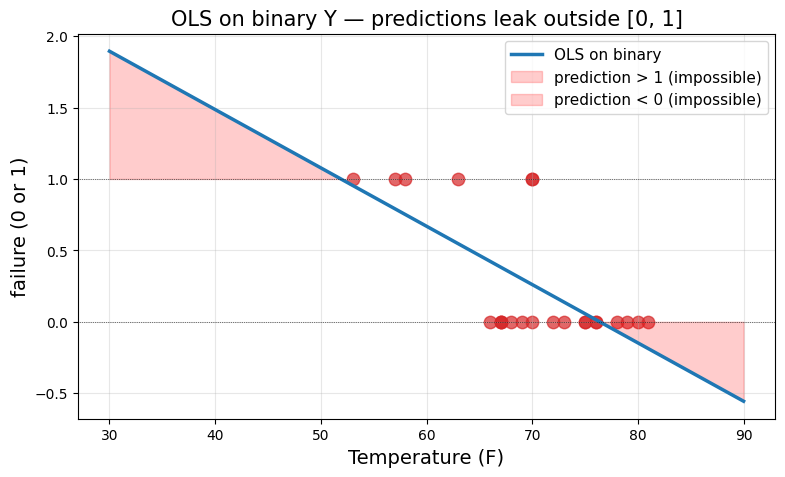


OLS prediction at temp=30: 1.894  (probability > 1!)
OLS prediction at temp=90: -0.556  (probability < 0!)


In [7]:
y_pred_bin = model_lin_bin.predict(grid_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(data['temp'], data['failure'], s=80, alpha=0.7, color='tab:red')
ax.plot(temp_grid, y_pred_bin, color='tab:blue', linewidth=2.5, label='OLS on binary')
ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.axhline(1, color='black', linewidth=0.5, linestyle=':')
ax.fill_between(temp_grid, y_pred_bin, 1.0, where=(y_pred_bin > 1), color='red', alpha=0.2,
                label='prediction > 1 (impossible)')
ax.fill_between(temp_grid, y_pred_bin, 0.0, where=(y_pred_bin < 0), color='red', alpha=0.2,
                label='prediction < 0 (impossible)')
ax.set_xlabel('Temperature (F)', fontsize=14)
ax.set_ylabel('failure (0 or 1)', fontsize=14)
ax.set_title('OLS on binary Y — predictions leak outside [0, 1]', fontsize=15)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.show()

print(f'\nOLS prediction at temp=30: {y_pred_bin.iloc[0]:.3f}  (probability > 1!)')
print(f'OLS prediction at temp=90: {y_pred_bin.iloc[-1]:.3f}  (probability < 0!)')

<h2 dir="rtl">פרק 5 — פונקציית sigmoid</h2>

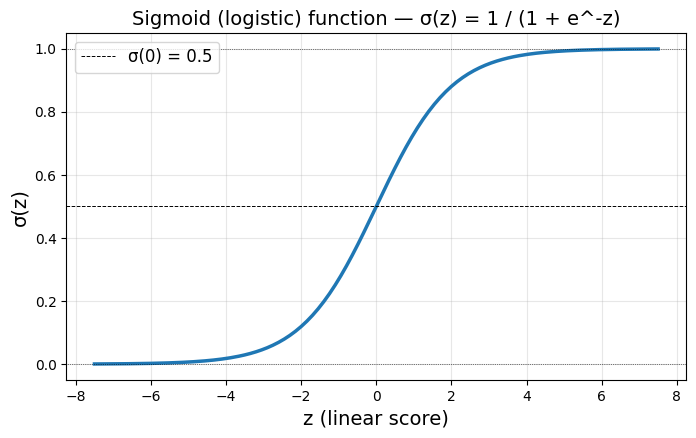

σ(-100) ≈ 3.7201e-44
σ(-3)   = 0.0474
σ(0)    = 0.5000
σ(+3)   = 0.9526
σ(+100) ≈ 1.0000


In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_grid = np.linspace(-7.5, 7.5, 200)
s_vals = sigmoid(z_grid)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(z_grid, s_vals, color='tab:blue', linewidth=2.5)
ax.axhline(0.5, color='black', linewidth=0.7, linestyle='--', label='σ(0) = 0.5')
ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.axhline(1, color='black', linewidth=0.5, linestyle=':')
ax.set_xlabel('z (linear score)', fontsize=14)
ax.set_ylabel('σ(z)', fontsize=14)
ax.set_title('Sigmoid (logistic) function — σ(z) = 1 / (1 + e^-z)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.show()

print(f'σ(-100) ≈ {sigmoid(-100):.4e}')
print(f'σ(-3)   = {sigmoid(-3):.4f}')
print(f'σ(0)    = {sigmoid(0):.4f}')
print(f'σ(+3)   = {sigmoid(3):.4f}')
print(f'σ(+100) ≈ {sigmoid(100):.4f}')

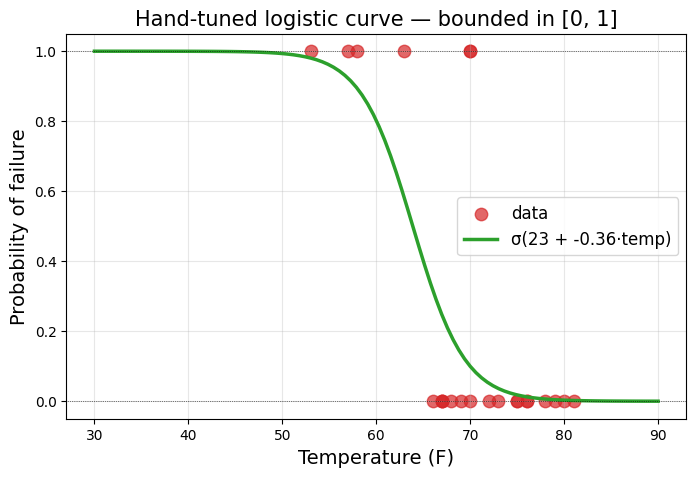

In [9]:
# Hand-tuned demo — what would beta0=23, beta1=-0.36 look like on Challenger temp range?
b0_demo, b1_demo = 23, -0.36
z_demo = b0_demo + b1_demo * temp_grid
p_demo = sigmoid(z_demo)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(data['temp'], data['failure'], s=80, alpha=0.7, color='tab:red', label='data')
ax.plot(temp_grid, p_demo, color='tab:green', linewidth=2.5, label=f'σ({b0_demo} + {b1_demo}·temp)')
ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.axhline(1, color='black', linewidth=0.5, linestyle=':')
ax.set_xlabel('Temperature (F)', fontsize=14)
ax.set_ylabel('Probability of failure', fontsize=14)
ax.set_title('Hand-tuned logistic curve — bounded in [0, 1]', fontsize=15)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.show()

<h2 dir="rtl">פרק 6 — `sm.Logit` + פירוש ה-summary</h2>

In [10]:
model_logit = sm.Logit(data['failure'], data[['intercept', 'temp']]).fit()
print(model_logit.summary())

print()
print(f"Pseudo R² (McFadden): {model_logit.prsquared:.4f}")
print(f"AIC: {model_logit.aic:.2f}")
print(f"BIC: {model_logit.bic:.2f}")
print(f"Log-Likelihood: {model_logit.llf:.4f}")

Optimization terminated successfully.
         Current function value: 0.307452
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                failure   No. Observations:                   23
Model:                          Logit   Df Residuals:                       21
Method:                           MLE   Df Model:                            1
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.4643
Time:                        15:59:38   Log-Likelihood:                -7.0714
converged:                       True   LL-Null:                       -13.201
Covariance Type:            nonrobust   LLR p-value:                 0.0004629
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     23.2216     11.485      2.022      0.043       0.712      45.731
temp          -0.3576      0.

<h2 dir="rtl">פרק 7 — תחזית עם `predict()` + נקודת ה-Challenger</h2>

Predicted P(failure | temp=30.5°F) = 1.0000


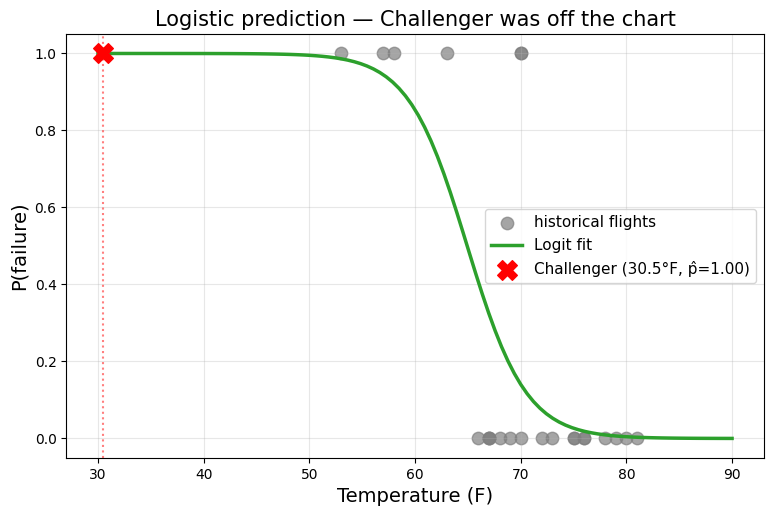

In [11]:
grid_df['p_pred'] = model_logit.predict(grid_df[['intercept', 'temp']])

# Challenger temperature
challenger_temp = 30.5
p_challenger = model_logit.predict(pd.DataFrame({'intercept':[1], 'temp':[challenger_temp]})).iloc[0]
print(f'Predicted P(failure | temp=30.5°F) = {p_challenger:.4f}')

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(data['temp'], data['failure'], s=80, alpha=0.7, color='tab:gray', label='historical flights')
ax.plot(grid_df['temp'], grid_df['p_pred'], color='tab:green', linewidth=2.5, label='Logit fit')
ax.scatter([challenger_temp], [1], s=200, color='red', marker='X', zorder=5,
           label=f'Challenger (30.5°F, p̂={p_challenger:.2f})')
ax.axvline(challenger_temp, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Temperature (F)', fontsize=14)
ax.set_ylabel('P(failure)', fontsize=14)
ax.set_title('Logistic prediction — Challenger was off the chart', fontsize=15)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.show()

<h2 dir="rtl">פרק 8 — logit ו-odds ratio</h2>

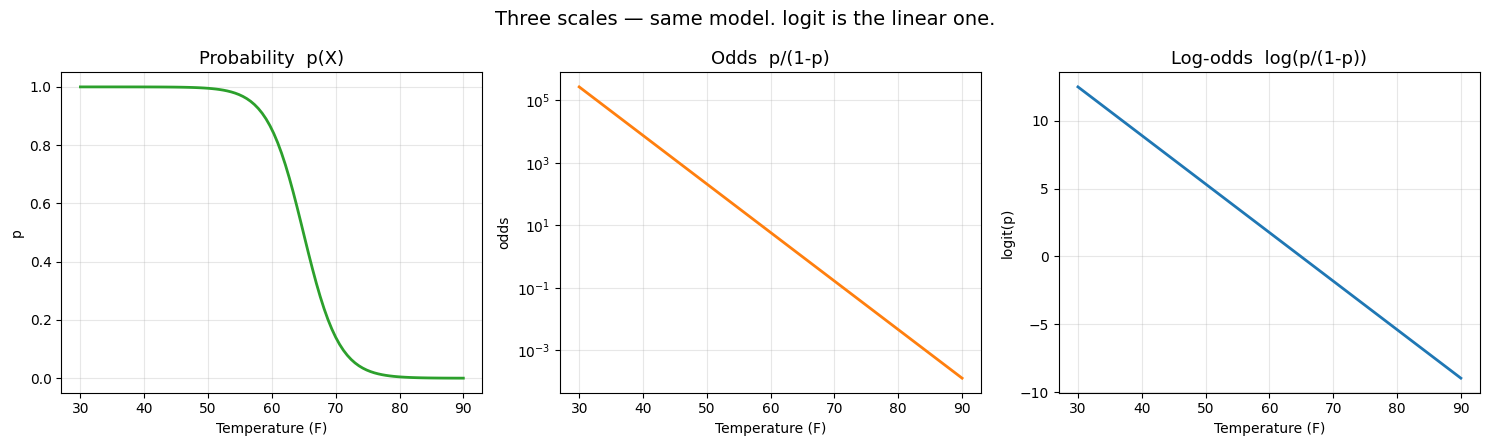


β₁ (temp coefficient) = -0.3576
Odds Ratio = exp(β₁) = 0.6994
Interpretation: every +1°F multiplies the odds by 0.699 (drops by 30.1%)
Or: every -1°F multiplies the odds by 1.430 (rises by 43.0%)


In [12]:
grid_df['odds'] = grid_df['p_pred'] / (1 - grid_df['p_pred'])
grid_df['log_odds'] = np.log(grid_df['odds'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(grid_df['temp'], grid_df['p_pred'], color='tab:green', linewidth=2)
axes[0].set_title('Probability  p(X)', fontsize=13)
axes[0].set_xlabel('Temperature (F)')
axes[0].set_ylabel('p')
axes[0].grid(alpha=0.3)

axes[1].plot(grid_df['temp'], grid_df['odds'], color='tab:orange', linewidth=2)
axes[1].set_title('Odds  p/(1-p)', fontsize=13)
axes[1].set_xlabel('Temperature (F)')
axes[1].set_ylabel('odds')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)

axes[2].plot(grid_df['temp'], grid_df['log_odds'], color='tab:blue', linewidth=2)
axes[2].set_title('Log-odds  log(p/(1-p))', fontsize=13)
axes[2].set_xlabel('Temperature (F)')
axes[2].set_ylabel('logit(p)')
axes[2].grid(alpha=0.3)

plt.suptitle('Three scales — same model. logit is the linear one.', fontsize=14)
plt.tight_layout()
plt.show()

odds_ratio = np.exp(model_logit.params['temp'])
print(f'\nβ₁ (temp coefficient) = {model_logit.params["temp"]:.4f}')
print(f'Odds Ratio = exp(β₁) = {odds_ratio:.4f}')
print(f'Interpretation: every +1°F multiplies the odds by {odds_ratio:.3f} (drops by {(1-odds_ratio)*100:.1f}%)')
print(f'Or: every -1°F multiplies the odds by {1/odds_ratio:.3f} (rises by {(1/odds_ratio - 1)*100:.1f}%)')

<h2 dir="rtl">פרק 9 — סיכום + הצצה לשיעור 08</h2>

### Write your answer here.

<div dir="rtl">

על דאטה Challenger, אמדנו $\hat p = \sigma(23.22 - 0.358 \cdot \text{temp})$. **חשב ידנית** (או עם python):

- (א) ההסתברות לכשל בטמפ' $50°F$?
- (ב) ה-odds בטמפ' $50°F$?
- (ג) פי כמה הם גדולים מה-odds בטמפ' $80°F$?

</div>